<a href="https://colab.research.google.com/github/prnakyazze94/Data-608/blob/main/Story_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
pip install pandas xlrd

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns



Metro_url = "https://raw.githubusercontent.com/prnakyazze94/Data-608/refs/heads/main/Metro.xls"
emp_url =    "https://raw.githubusercontent.com/prnakyazze94/Data-608/refs/heads/main/Employment_projections"
state_url = "https://raw.githubusercontent.com/prnakyazze94/Data-608/refs/heads/main/Data_state_demand"
wage_url = "https://raw.githubusercontent.com/prnakyazze94/Data-608/refs/heads/main/Data_hourly_annual_wage"
Data_ind_url = "https://raw.githubusercontent.com/prnakyazze94/Data-608/refs/heads/main/Data_practitioner_industries"
salaryState_url = "https://raw.githubusercontent.com/prnakyazze94/Data-608/refs/heads/main/Data_Practitioner_salaryState"

Metro_df = pd.read_csv(Metro_url, sep="\t")
emp_df = pd.read_csv(emp_url, sep="\t")
state_df = pd.read_csv(state_url, sep="\t")
wage_df = pd.read_csv(wage_url, sep="\t")
Data_ind_df = pd.read_csv(Data_ind_url, sep="\t")
salaryState_df = pd.read_csv(salaryState_url, sep="\t")


print(Metro_df.head())
print(emp_df.head())
print(state_df.head())
print(wage_df.head())
print(Data_ind_df.head())
print(salaryState_df)

                                   Metropolitan Employment             Role
0            New York-Newark-Jersey City, NY-NJ     19,810  Data Scientists
1            Los Angeles-Long Beach-Anaheim, CA     10,030  Data Scientists
2             San Francisco-Oakland-Fremont, CA      9,350  Data Scientists
3               Dallas-Fort Worth-Arlington, TX      8,630  Data Scientists
4  Washington-Arlington-Alexandria, DC-VA-MD-WV      8,530  Data Scientists
  Employment_Available Mean Hourly Wage Mean Annual Wage  \
0              233,440          $59.90         $124,590    
1               73,180          $51.65         $107,440    
2               64,770          $68.57         $142,620    
3               29,800          $54.01         $112,330    
4              107,760          $47.66          $99,120    

                      Role  
0          Data Scientists  
1  Database Administrators  
2      Database Architects  
3            Statisticians  
4                 Analysts  
         

In [6]:
emp_df["Employment_Available"].dtype

dtype('O')

In [4]:
emp_df["Employment_Available"] = (
    emp_df["Employment_Available"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(int)
)

How much do we make

In [7]:
wage_df.columns = wage_df.columns.str.strip()
print(wage_df.columns)

emp_df.columns = emp_df.columns.str.strip()
print(emp_df.columns)



Index(['Percentile', '10%', '25%', '50%', '75%', '90%', 'Role'], dtype='object')
Index(['Employment_Available', 'Mean Hourly Wage', 'Mean Annual Wage', 'Role'], dtype='object')


In [6]:
emp_df["Mean Hourly Wage"] = (
    emp_df["Mean Hourly Wage"]
    .replace(r'[\$,]', '', regex=True)
    .astype(float)
)

emp_df["Mean Annual Wage"] = (
    emp_df["Mean Annual Wage"]
    .replace(r'[\$,]', '', regex=True)
    .astype(float)
)

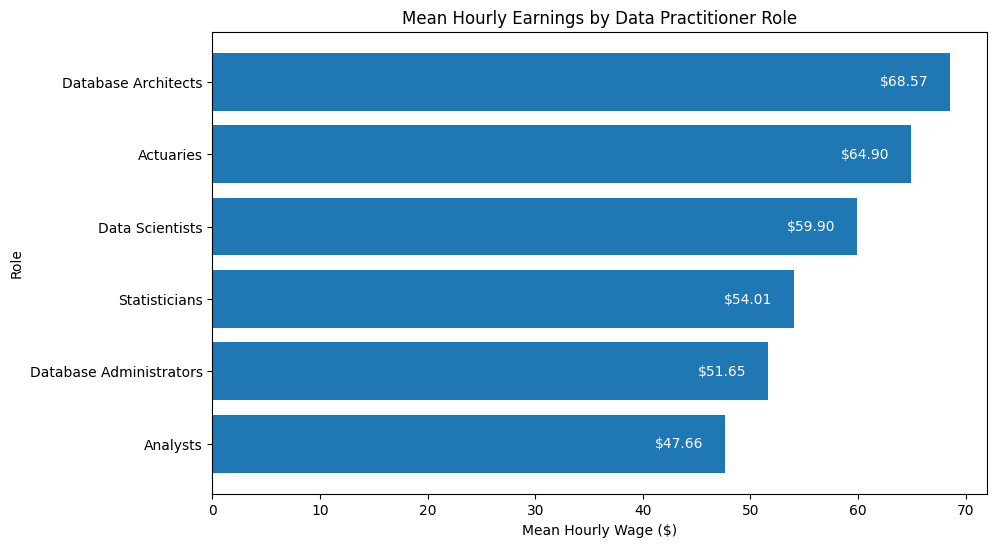

In [38]:


hourly_sorted = emp_df.sort_values("Mean Hourly Wage", ascending=True)

plt.figure(figsize=(10,6))

bars = plt.barh(hourly_sorted["Role"], hourly_sorted["Mean Hourly Wage"])

plt.title("Mean Hourly Earnings by Data Practitioner Role")
plt.xlabel("Mean Hourly Wage ($)")
plt.ylabel("Role")

# Labels inside bars
for bar in bars:
    width = bar.get_width()
    plt.text(width - 2, bar.get_y() + bar.get_height()/2,
             f"${width:.2f}",
             va='center', ha='right', color='white')

plt.show()

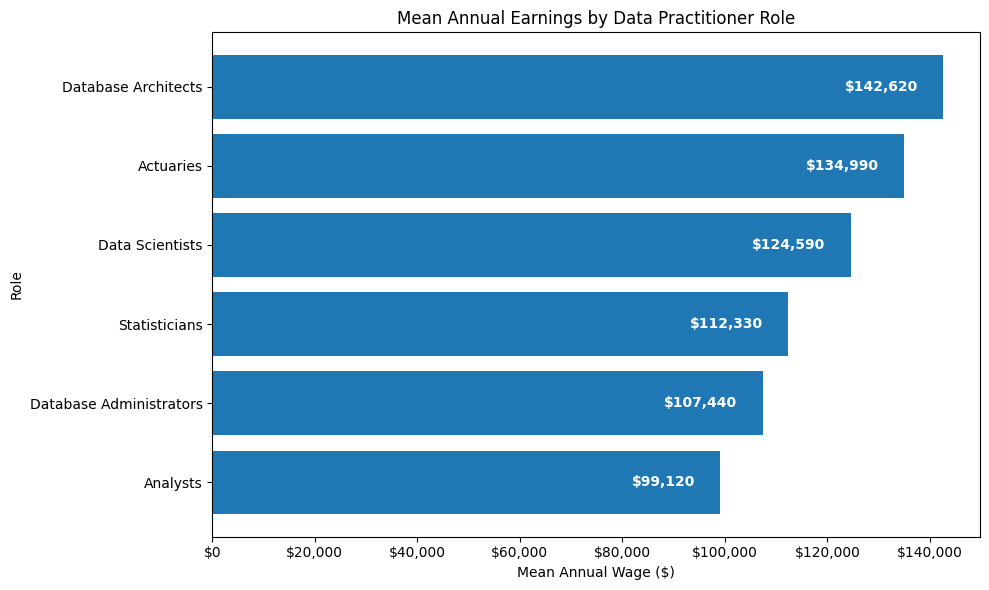

In [39]:


# Sort the data
annual_sorted = emp_df.sort_values("Mean Annual Wage", ascending=True)

plt.figure(figsize=(10,6))

# Create the horizontal bar chart
bars = plt.barh(annual_sorted["Role"], annual_sorted["Mean Annual Wage"])

plt.title("Mean Annual Earnings by Data Practitioner Role")
plt.xlabel("Mean Annual Wage ($)")
plt.ylabel("Role")

# Add wage labels inside the bars
for bar in bars:
    width = bar.get_width()
    # Adjust the position (width - offset) and horizontal alignment (ha) as needed
    plt.text(width - 5000,                      # X position: slightly inside the end of the bar
             bar.get_y() + bar.get_height()/2,  # Y position: center of the bar
             f'${width:,.0f}',                  # Label text formatted with $ and commas
             va='center',
             ha='right',
             color='white',
             fontweight='bold')

# Format the x-axis with commas and dollar signs
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

# Adjust layout to make sure labels fit
plt.tight_layout()
plt.show()

In [36]:
emp_df.columns = emp_df.columns.str.strip()

emp_df["Mean Annual Wage"] = (
    emp_df["Mean Annual Wage"]
    .replace(r'[\$,]', '', regex=True)
    .astype(float)
)

In [37]:
state_df.columns = state_df.columns.str.strip()

state_df["Employment"] = (
    state_df["Employment"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(int)
)

In [14]:
merged_df = pd.merge(state_df, emp_df[["Role", "Mean Annual Wage"]], on="Role", how="left")

In [16]:
top5 = state_df.sort_values(by="Employment", ascending=False).head(5)

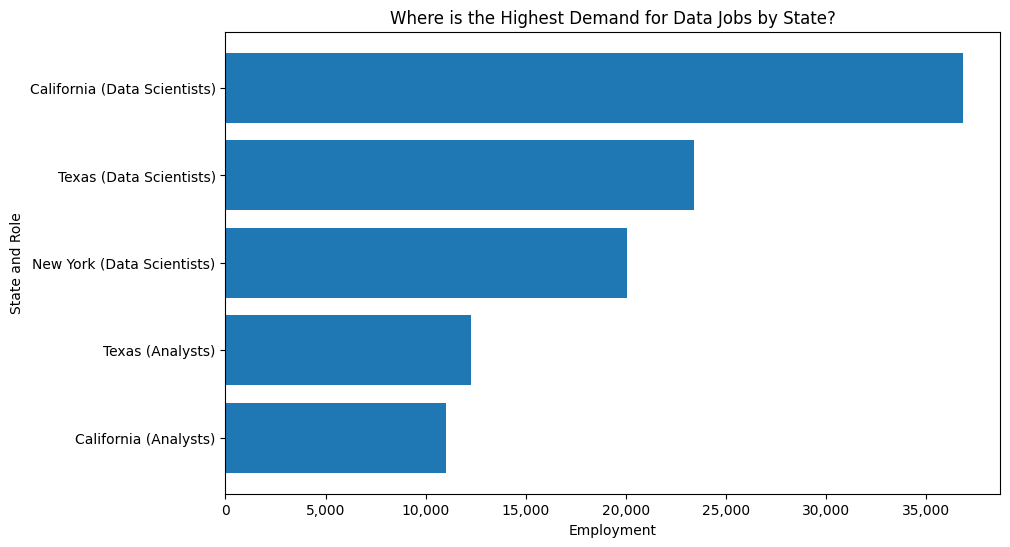

In [17]:


plt.figure(figsize=(10,6))

# Combine State + Role for better labels
labels = top5["State"] + " (" + top5["Role"] + ")"

plt.barh(labels, top5["Employment"])

plt.xlabel("Employment")
plt.ylabel("State and Role")
plt.title("Where is the Highest Demand for Data Jobs by State?")

# Format axis
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Put highest at top
plt.gca().invert_yaxis()

plt.show()

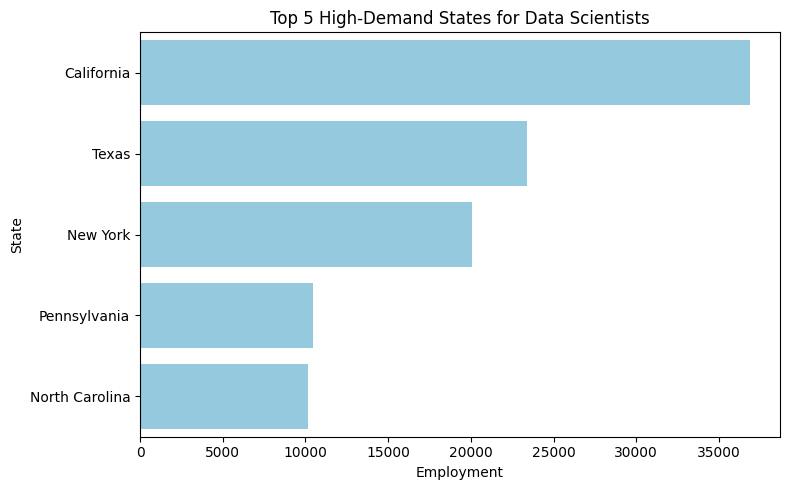

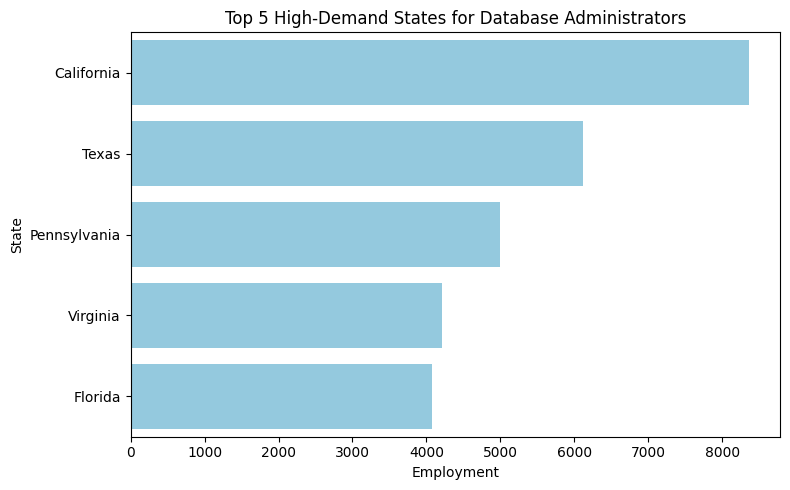

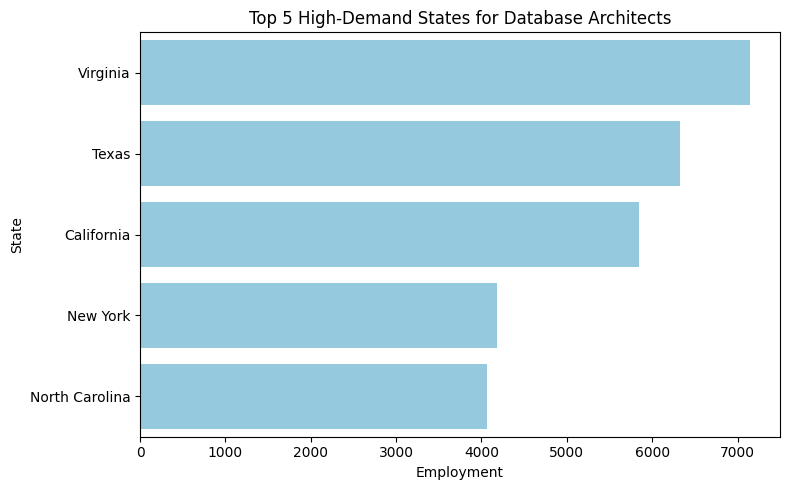

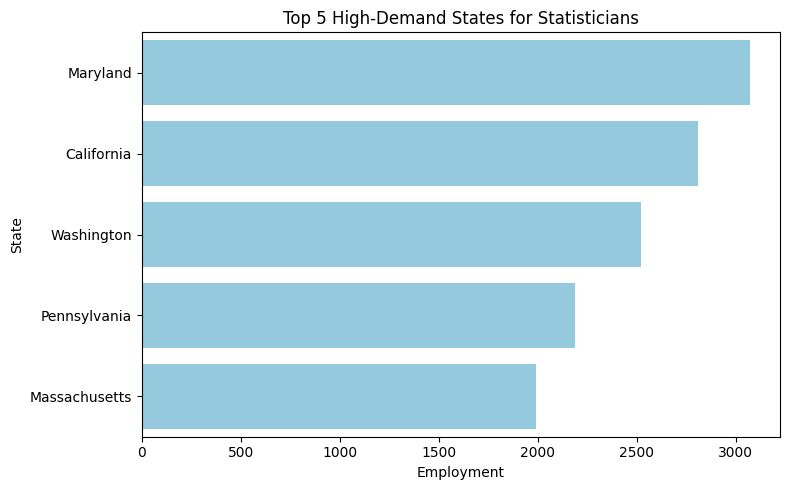

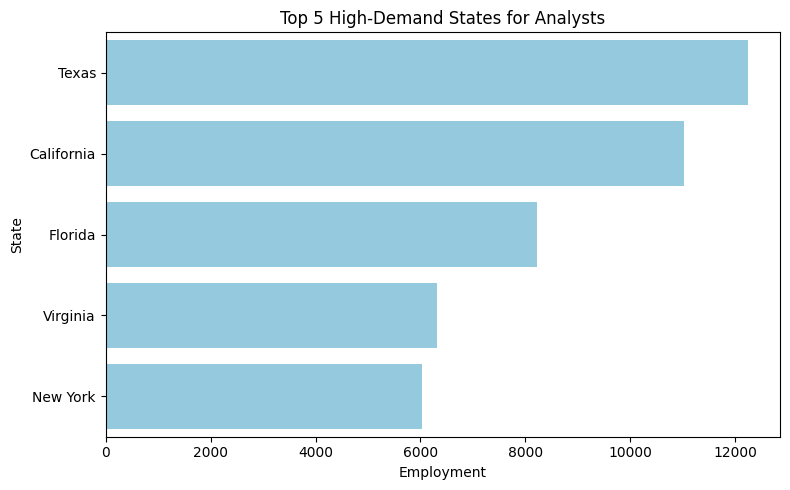

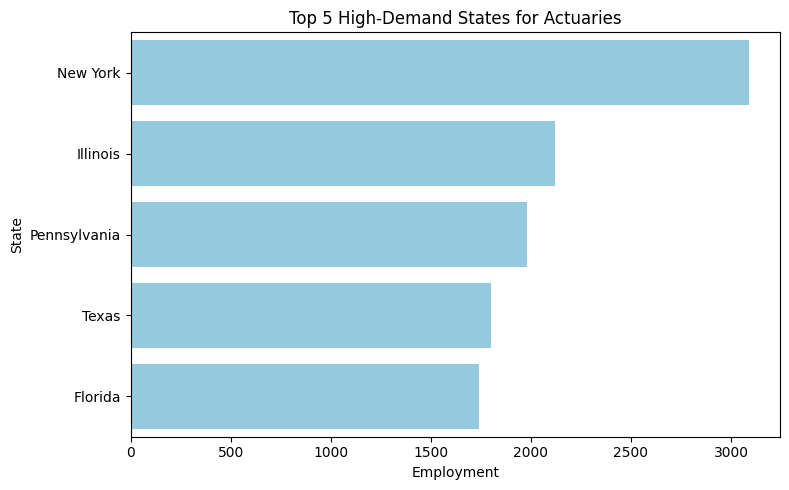

In [19]:


# Clean Employment
state_df["Employment"] = (
    state_df["Employment"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(int)
)

# Get unique roles (limit to 6 if needed)
roles = state_df["Role"].unique()[:6]

# Loop through each role and create a plot
for role in roles:

    role_df = (
        state_df[state_df["Role"] == role]
        .sort_values("Employment", ascending=False)
        .head(5)
    )

    plt.figure(figsize=(8,5))

    sns.barplot(
        data=role_df,
        x="Employment",
        y="State",
        order=role_df["State"],  # ensures sorted order
        color="skyblue"
    )

    plt.title(f"Top 5 High-Demand States for {role}")
    plt.xlabel("Employment")
    plt.ylabel("State")

    plt.tight_layout()
    plt.show()

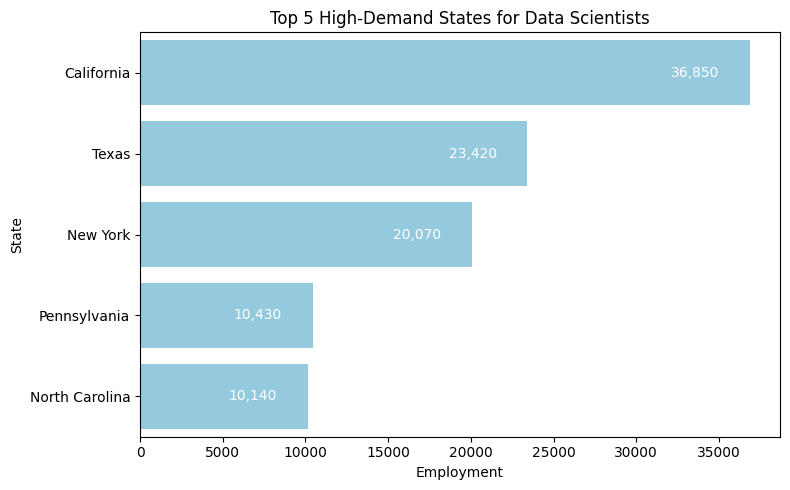

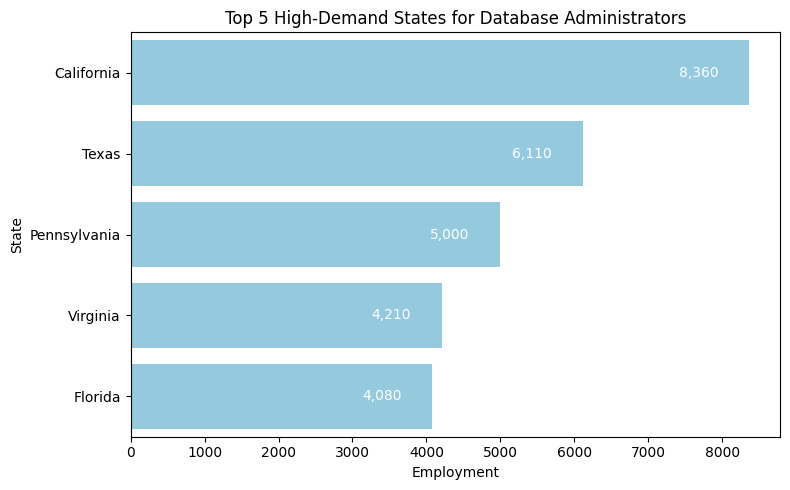

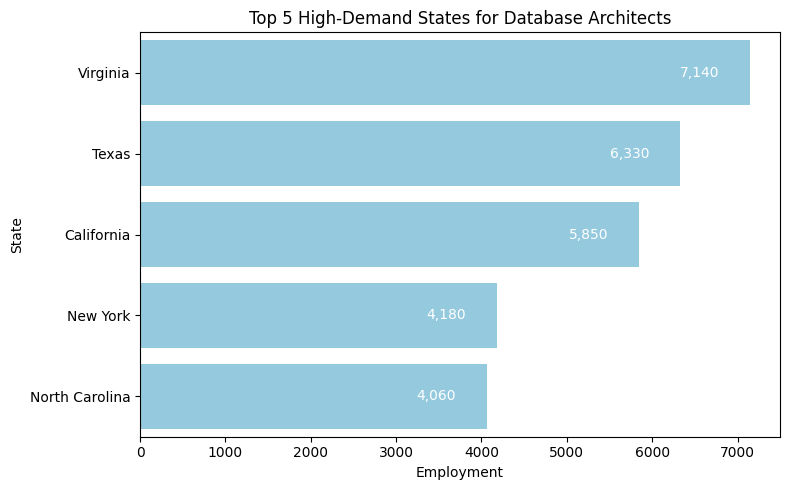

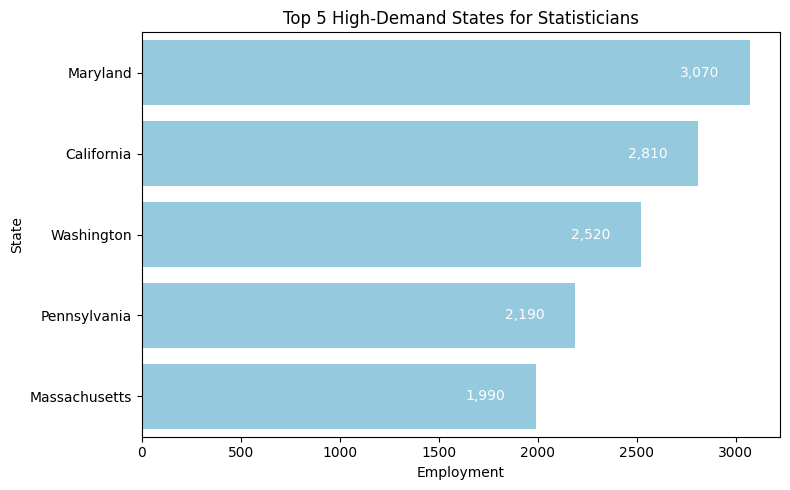

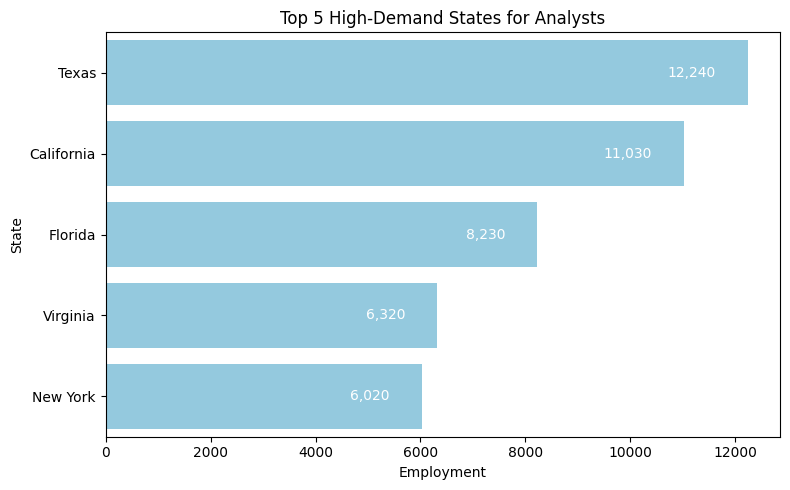

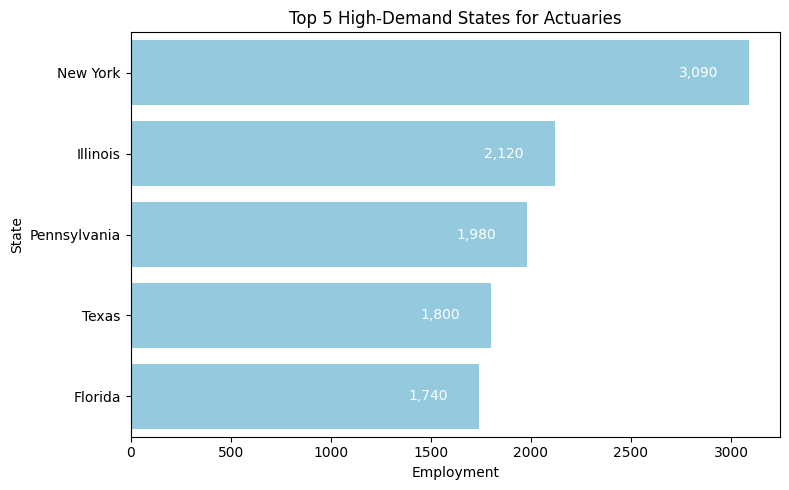

In [20]:

# Clean Employment
state_df["Employment"] = (
    state_df["Employment"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(int)
)

# Get unique roles (limit to 6 if needed)
roles = state_df["Role"].unique()[:6]

# Loop through each role and create a plot
for role in roles:

    role_df = (
        state_df[state_df["Role"] == role]
        .sort_values("Employment", ascending=False)
        .head(5)
    )

    plt.figure(figsize=(8,5))

    ax = sns.barplot(
        data=role_df,
        x="Employment",
        y="State",
        order=role_df["State"],
        color="skyblue"
    )

    # Add labels inside bars
    for i, v in enumerate(role_df["Employment"]):
        ax.text(
            v - (0.05 * role_df["Employment"].max()),  # move inside bar
            i,
            f"{v:,}",
            va='center',
            ha='right',
            color='white'
        )

    plt.title(f"Top 5 High-Demand States for {role}")
    plt.xlabel("Employment")
    plt.ylabel("State")

    plt.tight_layout()
    plt.show()

In [62]:
heatmap_df = state_df.pivot_table(
    index="State",
    columns="Role",
    values="Employment",
    aggfunc="sum",
    fill_value=0
)


In [63]:
heatmap_df["Total_by_State"] = heatmap_df.sum(axis=1)

In [64]:
total_row = heatmap_df.sum(axis=0)
heatmap_df.loc["Total_by_Role"] = total_row

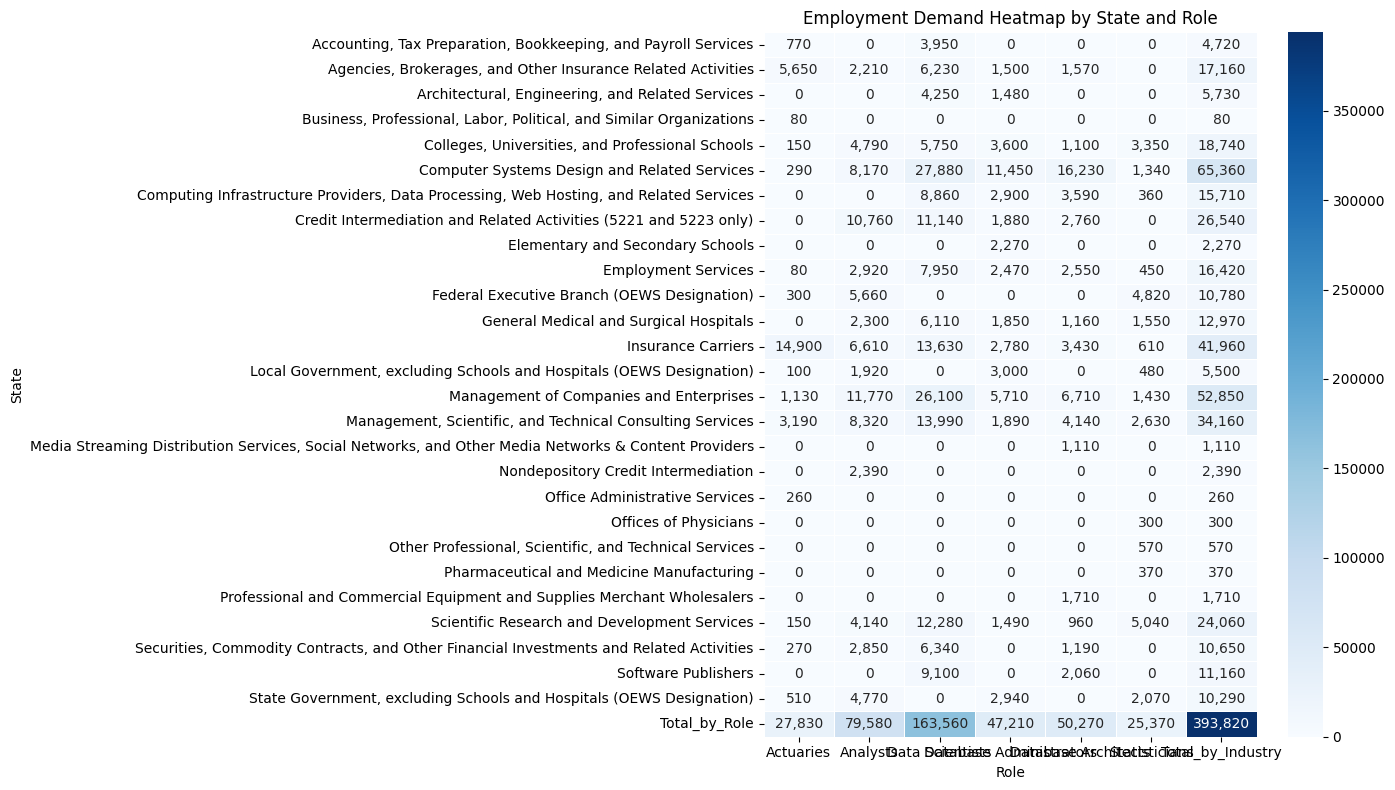

In [87]:


plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=",",
    linewidths=0.5,
    cmap="Blues"   # ✅ skyblue → dark blue gradient
)

plt.title("Employment Demand Heatmap by State and Role")

plt.ylabel("State")
plt.xlabel("Role")

# Keep role labels horizontal
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

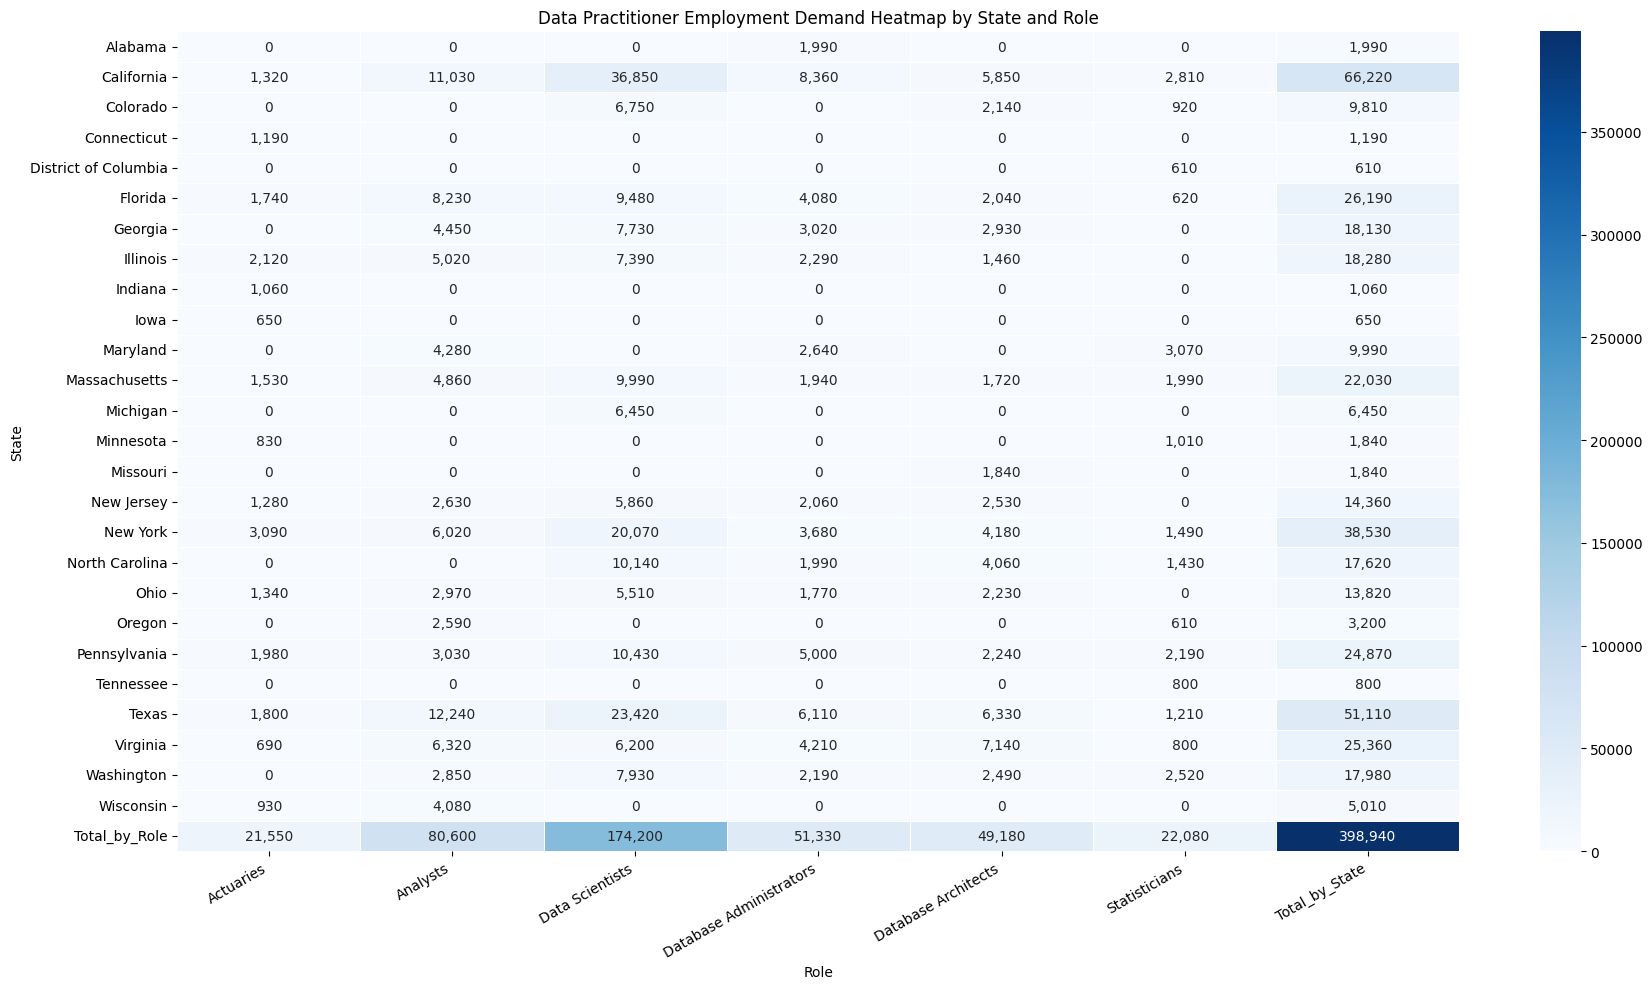

In [94]:
plt.figure(figsize=(18,10))  # ✅ wider figure

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=",",
    linewidths=0.5,
    cmap="Blues"
)

plt.title("Data Practitioner Employment Demand Heatmap by State and Role")

plt.ylabel("State")
plt.xlabel("Role")

# Improve column label readability
plt.xticks(rotation=30, ha='right')  # slight angle prevents overlap

plt.tight_layout()
plt.show()

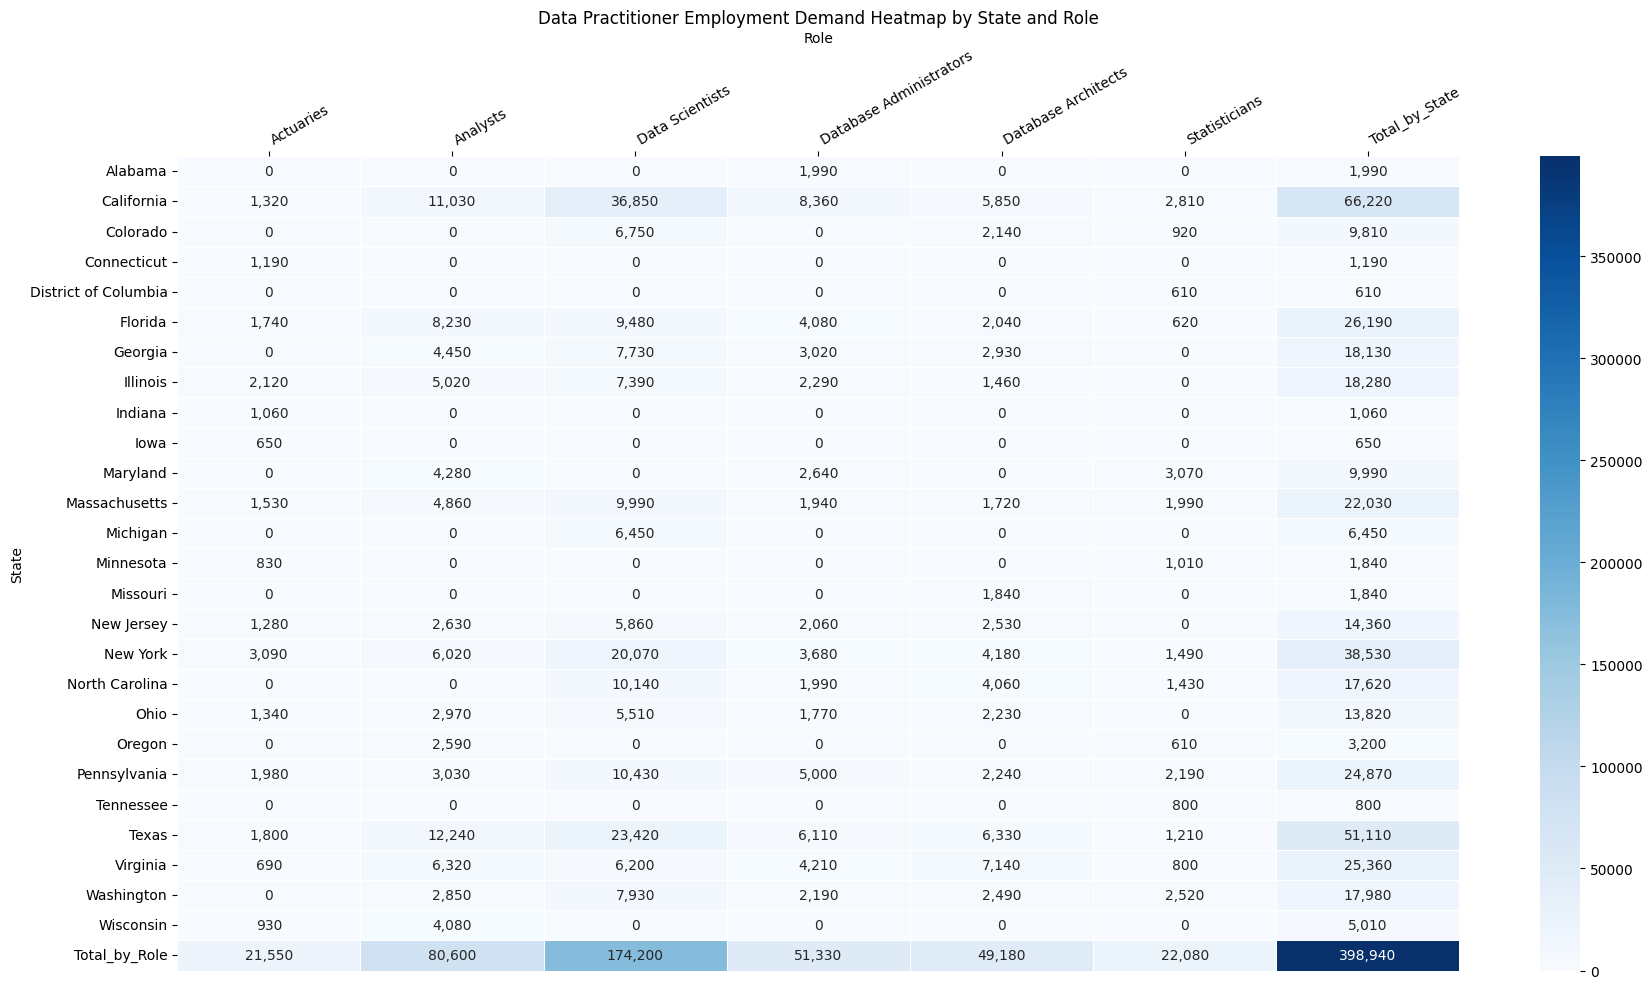

In [93]:
plt.figure(figsize=(18,10))

ax = sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=",",
    linewidths=0.5,
    cmap="Blues"
)

plt.title("Data Practitioner Employment Demand Heatmap by State and Role")

plt.ylabel("State")
plt.xlabel("Role")

# Move role labels to top
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

# Improve readability
plt.xticks(rotation=30, ha='left')

plt.tight_layout()
plt.show()

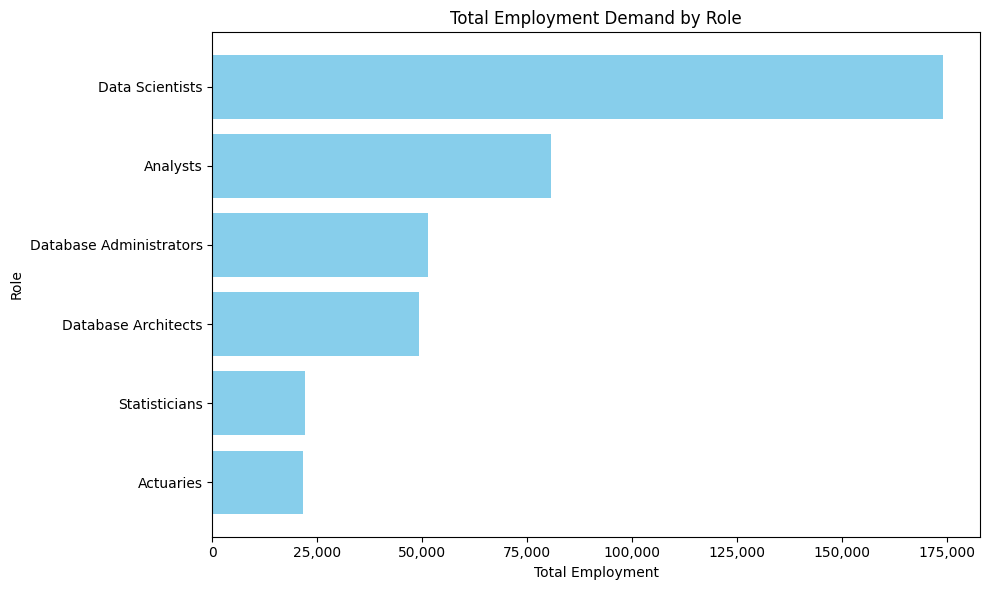

In [68]:


# Extract totals row (exclude Total_by_State column)
role_totals = heatmap_df.loc["Total_by_Role"].drop("Total_by_State")

# Convert to DataFrame for plotting
role_totals = role_totals.reset_index()
role_totals.columns = ["Role", "Total_Employment"]

# Sort from smallest → largest (so biggest is on top)
role_totals = role_totals.sort_values("Total_Employment", ascending=True)

# Plot
plt.figure(figsize=(10,6))

plt.barh(role_totals["Role"], role_totals["Total_Employment"], color="skyblue")

plt.title("Total Employment Demand by Role")
plt.xlabel("Total Employment")
plt.ylabel("Role")

# Format numbers
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

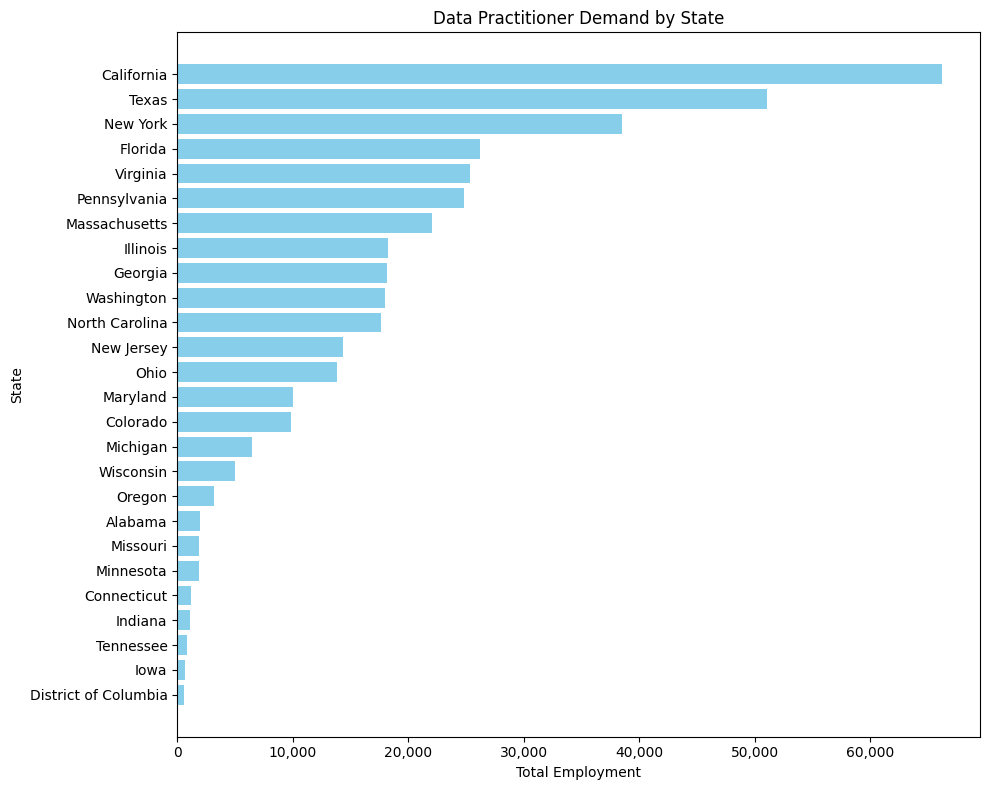

In [69]:


# Remove total row (keep only states)
state_totals = heatmap_df.drop("Total_by_Role")

# Extract Total_by_State column
state_totals = state_totals["Total_by_State"].reset_index()

# Rename columns
state_totals.columns = ["State", "Total_Employment"]

# Sort so highest appears at the top
state_totals = state_totals.sort_values("Total_Employment", ascending=True)

# Plot
plt.figure(figsize=(10,8))

bars = plt.barh(state_totals["State"], state_totals["Total_Employment"], color="skyblue")

plt.title("Data Practitioner Demand by State")
plt.xlabel("Total Employment")
plt.ylabel("State")

# Format axis with commas
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

In [70]:
top16_states = state_totals.sort_values("Total_Employment", ascending=False).head(16)

# Re-sort for plotting (small → large so biggest is on top)
top16_states = top16_states.sort_values("Total_Employment", ascending=True)

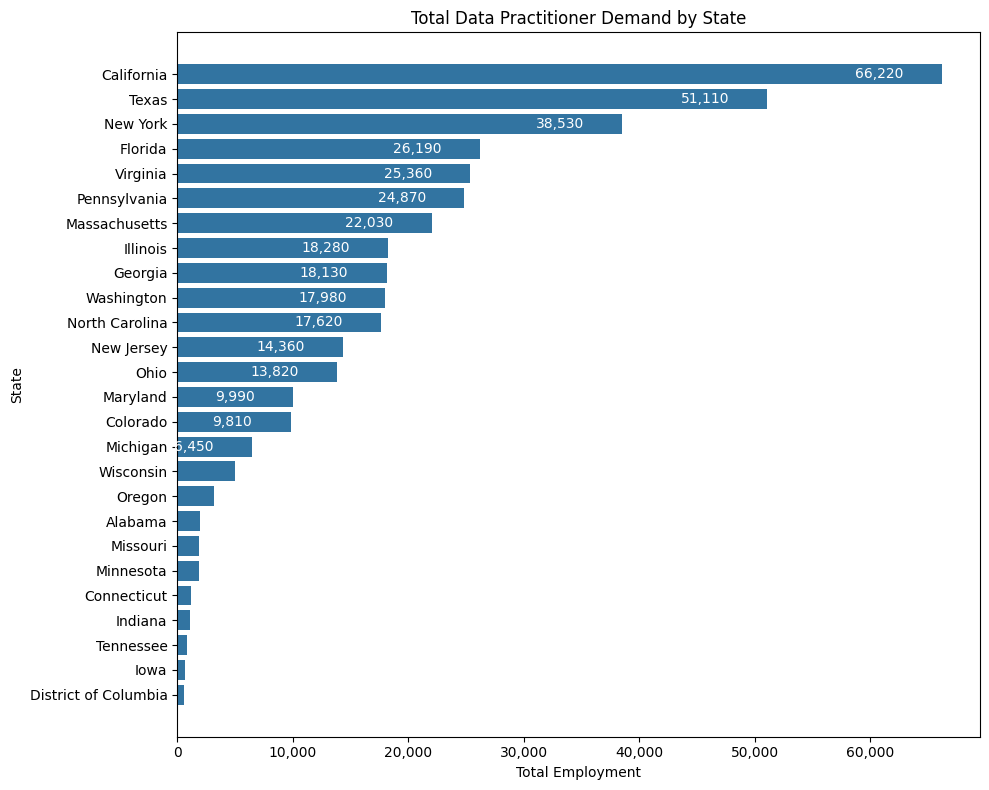

In [71]:
plt.figure(figsize=(10,8))

bars = plt.barh(state_totals["State"], state_totals["Total_Employment"], color="#3274A1")

# Identify top 16 states
top16_states = state_totals.nlargest(16, "Total_Employment")

max_val = state_totals["Total_Employment"].max()

# Add labels ONLY for top 16
for i, (state, value) in enumerate(zip(state_totals["State"], state_totals["Total_Employment"])):
    if state in top16_states["State"].values:
        plt.text(
            value - (0.05 * max_val),
            i,
            f"{value:,}",
            va='center',
            ha='right',
            color='white'
        )

plt.title("Total Data Practitioner Demand by State")
plt.xlabel("Total Employment")
plt.ylabel("State")

plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

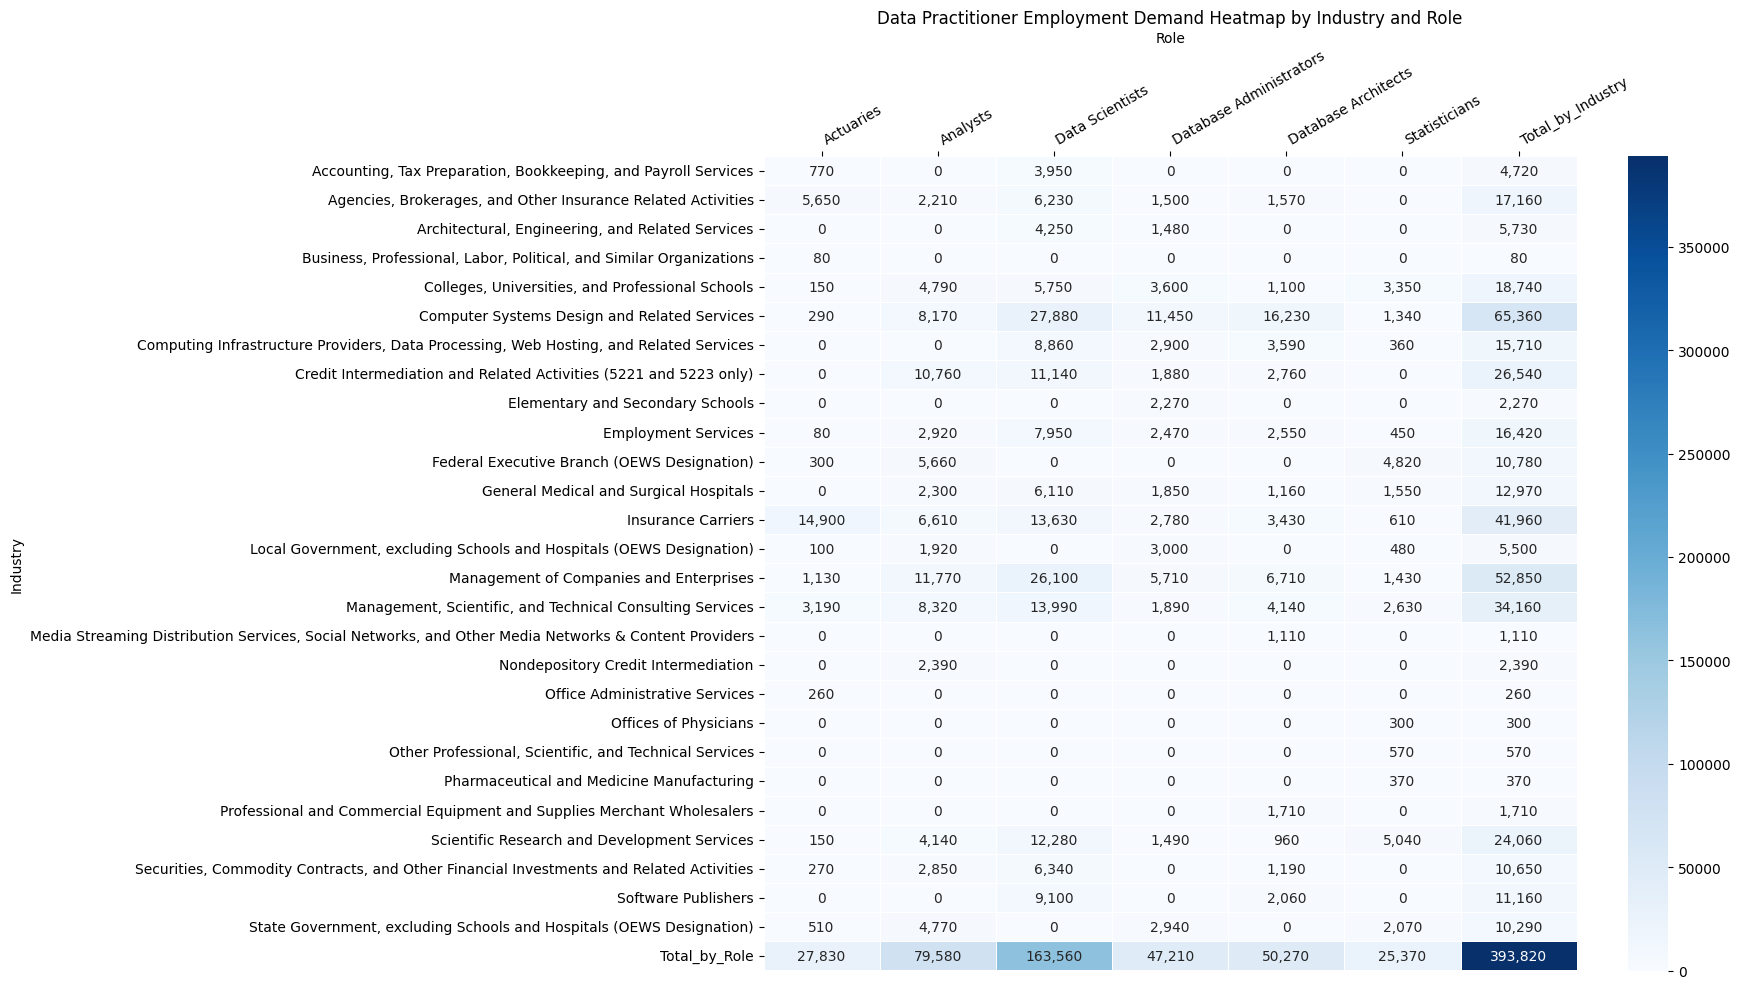

In [79]:


# 1. Clean Employment data (remove commas and convert to numeric)
Data_ind_df["Employment"] = (
    Data_ind_df["Employment"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(int)
)

# 2. Pivot the data: Industry on rows, Role on columns
heatmap_df = Data_ind_df.pivot_table(
    index="Industry",
    columns="Role",
    values="Employment",
    aggfunc="sum",
    fill_value=0
)

# 3. Add a column for Total by Industry
heatmap_df["Total_by_Industry"] = heatmap_df.sum(axis=1)

# 4. Add a row for Total by Role
total_row = heatmap_df.sum(axis=0)
heatmap_df.loc["Total_by_Role"] = total_row

# 5. Create the heatmap
plt.figure(figsize=(18, 10))

ax = sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=",",
    linewidths=0.5,
    cmap="Blues"
)

plt.title("Data Practitioner Employment Demand Heatmap by Industry and Role")
plt.ylabel("Industry")
plt.xlabel("Role")

# ✅ Move role labels to top
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

# Improve readability
plt.xticks(rotation=30, ha='left')

plt.tight_layout()
plt.show()

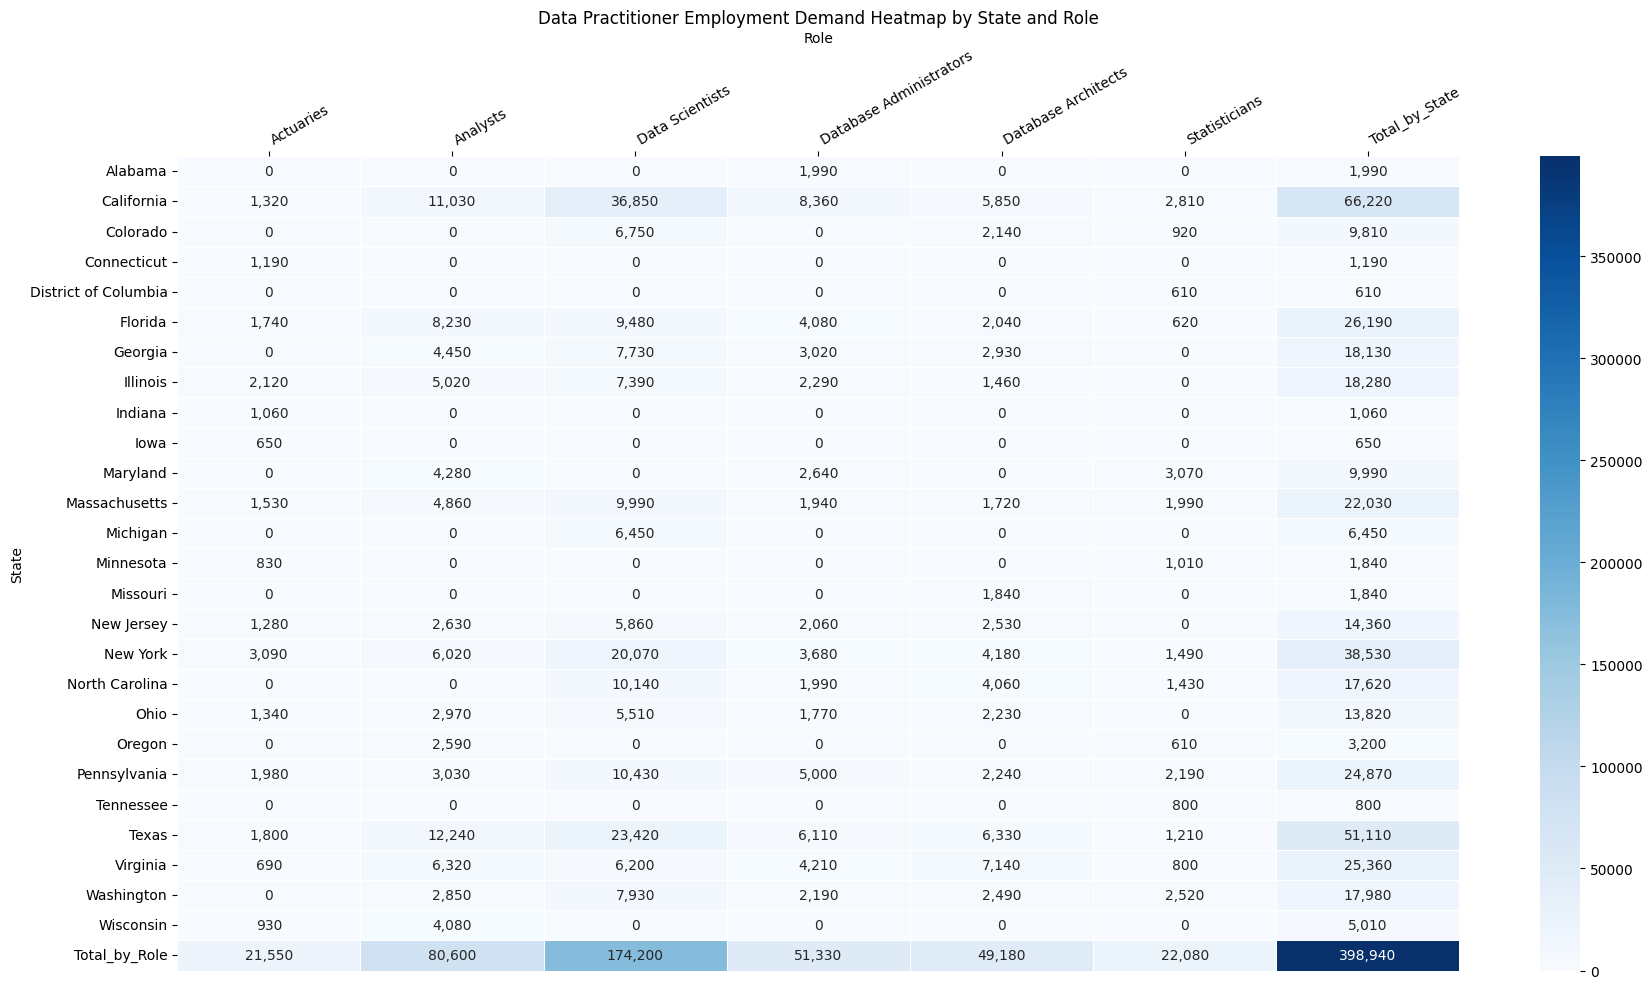

In [92]:
# 1. Clean Employment data
Data_ind_df["Employment"] = (
    Data_ind_df["Employment"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(int)
)

# 2. Pivot the data: State on rows, Role on columns
heatmap_df = state_df.pivot_table(
    index="State",
    columns="Role",
    values="Employment",
    aggfunc="sum",
    fill_value=0
)

# 3. Add a column for Total by State
heatmap_df["Total_by_State"] = heatmap_df.sum(axis=1)

# 4. Add a row for Total by Role
total_row = heatmap_df.sum(axis=0)
heatmap_df.loc["Total_by_Role"] = total_row

# 5. Create the heatmap
plt.figure(figsize=(18, 10))

ax = sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=",",
    linewidths=0.5,
    cmap="Blues"
)

plt.title("Data Practitioner Employment Demand Heatmap by State and Role")
plt.ylabel("State")
plt.xlabel("Role")

# Move role labels to top
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

# Improve readability
plt.xticks(rotation=30, ha='left')

plt.tight_layout()
plt.show()

Which industry is hiring data Practitioners

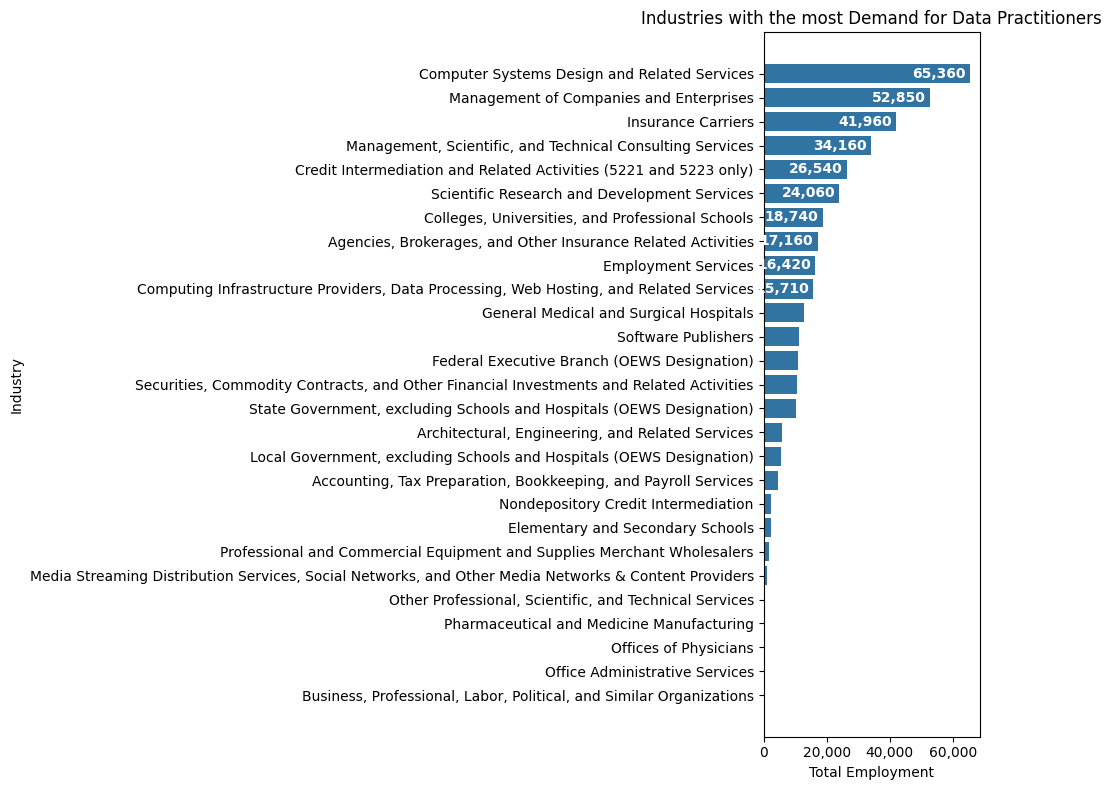

In [78]:


# 1. Prepare the industry data from heatmap_df
# Remove the "Total_by_Role" row so we only have individual industries
ind_totals = heatmap_df.drop("Total_by_Role", errors='ignore')

# Extract the 'Total_by_Industry' column and reset index to get Industry as a column
ind_totals = ind_totals["Total_by_Industry"].reset_index()
ind_totals.columns = ["Industry", "Total_Employment"]

# Sort ascending so the largest bars appear at the top of the horizontal chart
ind_totals = ind_totals.sort_values("Total_Employment", ascending=True)

# 2. Plotting
plt.figure(figsize=(10, 8))

bars = plt.barh(
    ind_totals["Industry"],
    ind_totals["Total_Employment"],
    color="#3274A1"
)

# Identify top industries for labels (using top 10 as an example)
top_n = 10
top_ind = ind_totals.nlargest(top_n, "Total_Employment")
max_val = ind_totals["Total_Employment"].max()

# Add labels ONLY for the top industries
for i, (industry, value) in enumerate(zip(ind_totals["Industry"], ind_totals["Total_Employment"])):
    if industry in top_ind["Industry"].values:
        plt.text(
            value - (0.02 * max_val),  # Position slightly inside the end of the bar
            i,
            f"{value:,}",
            va='center',
            ha='right',
            color='white',
            fontweight='bold'
        )

plt.title("Industries with the most Demand for Data Practitioners")
plt.xlabel("Total Employment")
plt.ylabel("Industry")

# Format the x-axis with commas
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

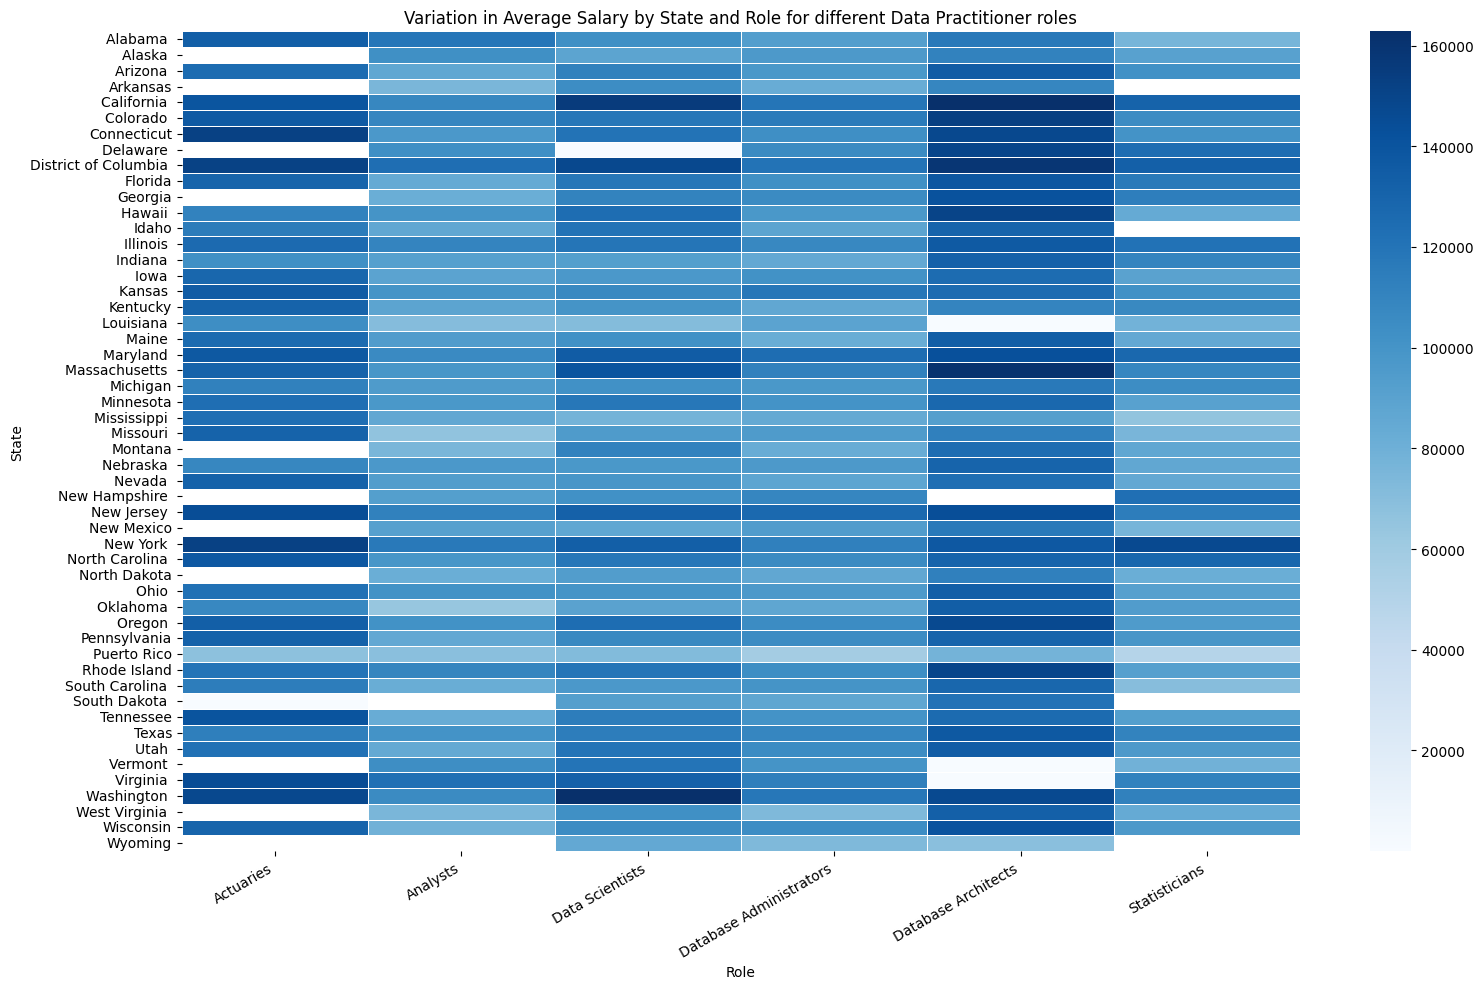

In [80]:


# Clean salary column
salaryState_df["Mean Annual Wage"] = (
    salaryState_df["Mean Annual Wage"]
    .replace(r'[\$,]', '', regex=True)
    .astype(float)
)

# Fix role naming if needed (optional but recommended)
salaryState_df["Role"] = salaryState_df["Role"].str.strip()

# Pivot: State × Role
salary_pivot = salaryState_df.pivot_table(
    index="State",
    columns="Role",
    values="Mean Annual Wage",
    aggfunc="mean"
)

# Plot heatmap
plt.figure(figsize=(16,10))

sns.heatmap(
    salary_pivot,
    cmap="Blues",
    annot=False,   # turn on if small dataset
    linewidths=0.5
)

plt.title("Variation in Average Salary by State and Role for different Data Practitioner roles")
plt.xlabel("Role")
plt.ylabel("State")

plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

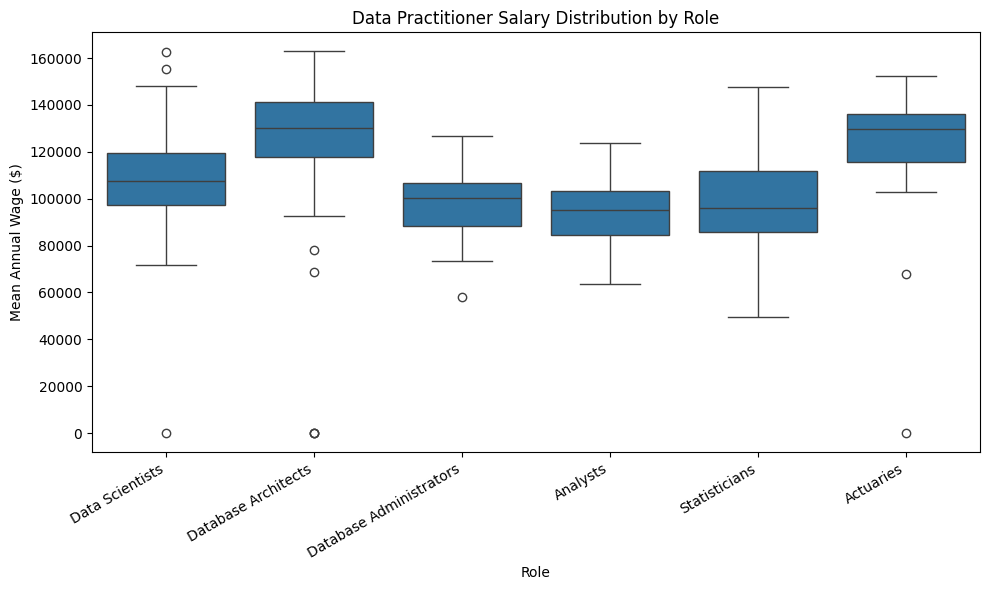

In [82]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=salaryState_df,
    x="Role",
    y="Mean Annual Wage"
)

plt.title("Data Practitioner Salary Distribution by Role")
plt.xlabel("Role")
plt.ylabel("Mean Annual Wage ($)")

plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

In [60]:


# Clean emp_df
emp_df["Employment_Available"] = (
    emp_df["Employment_Available"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(int)
)

emp_df["Mean Annual Wage"] = (
    emp_df["Mean Annual Wage"]
    .replace(r'[\$,]', '', regex=True)
    .astype(float)
)

# Keep only needed columns
plot_df = emp_df[["Role", "Employment_Available", "Mean Annual Wage"]]

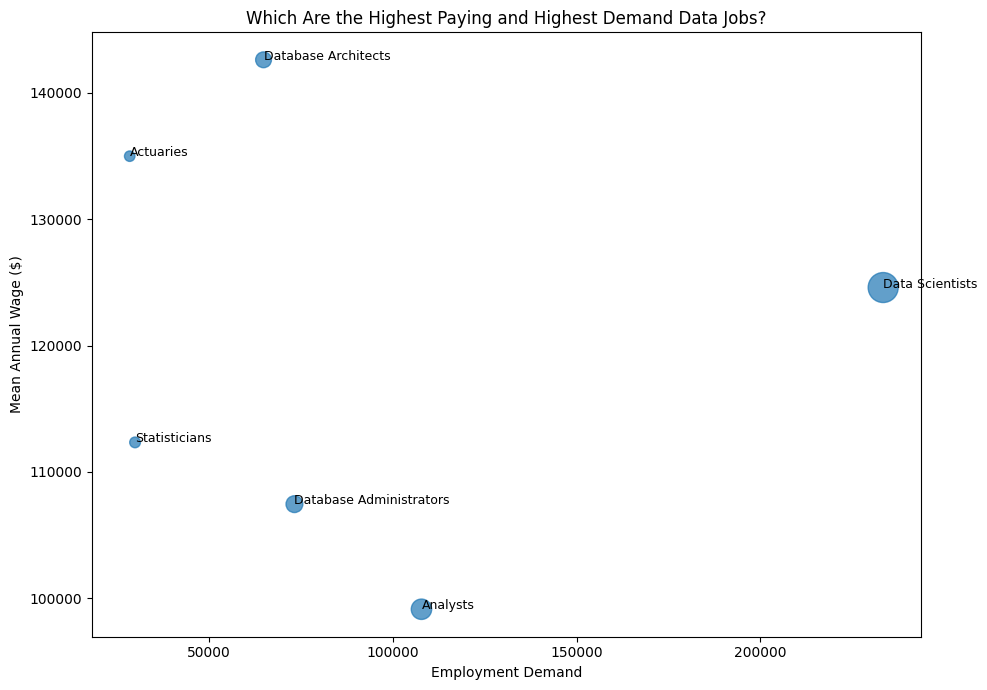

In [83]:


plt.figure(figsize=(10,7))

scatter = plt.scatter(
    plot_df["Employment_Available"],
    plot_df["Mean Annual Wage"],
    s=plot_df["Employment_Available"] / 500,  # scale bubble size
    alpha=0.7
)

# Add labels for each role
for i, row in plot_df.iterrows():
    plt.text(
        row["Employment_Available"],
        row["Mean Annual Wage"],
        row["Role"],
        fontsize=9
    )

plt.title("Which Are the Highest Paying and Highest Demand Data Jobs?")
plt.xlabel("Employment Demand")
plt.ylabel("Mean Annual Wage ($)")

plt.tight_layout()
plt.show()

Which industry is hiring data Practitioners